In [1]:
import os, sys, json, math, random
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
import hdf5plugin  # noqa: F401 — must precede first h5py file open
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path("/home/aaron/workspace/FailBench")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from torch.utils.data import DataLoader, Subset

from planner.risk.dataset_v2 import V2Source, PooledV2Dataset
from planner.risk.benchmark_dataset import (
      BenchmarkDataset, ModalityConfig, TargetConfig,
      demo_stratified_split, task_held_out_split,
) 

LIBERO_V2   = "/media/aaron/F/failbench/libero/v2"
ROBOCASA_V2 = "/media/aaron/F/failbench/robocasa/v2"
  
SOURCES = [
      V2Source.libero(LIBERO_V2, splits=("libero_spatial", "libero_object", "libero_goal")),
      V2Source.robocasa(ROBOCASA_V2),
]

### Layer A — BenchmarkDataset (training-ready, heatmap target included)

In [2]:
dataset = BenchmarkDataset(
    sources=SOURCES,
    modalities=ModalityConfig(
        state=True, goal=True,
        # rgb / depth OFF for this MLP baseline (build_input doesn't read them).
        rgb=False, depth=False,
        failure_mode=True, failure_joints=True,
    ),
    target_cfg=TargetConfig(sigma_px=4.0, log1p=True),
    use_window=True,
    # Use the precomputed projection cache (run scripts/data/precompute_targets.py
    # once if it's missing). Without it, target_log1p is recomputed per sample on
    # CPU. With it, the loader returns a small (N_i, 3) projection that the
    # trainer scatters + Gaussian-smooths on GPU — same target, ~3x faster epoch.
    target_cache_root="/media/aaron/F/failbench/target_cache",
)

# Confirm the quarantine is wired (V2Source auto-detects <root>/quarantine.csv).
for src in SOURCES:
    q = src.quarantine_path
    print(f"  source={src.name:10s} quarantine={q.name if q else 'NONE'}")
print(f"dataset: {len(dataset):,} trials  (pre-quarantine corpus was 52,500)")
print(f"target_cache: {dataset.target_cache_root}")


  source=libero     quarantine=quarantine.csv
  source=robocasa   quarantine=quarantine.csv
dataset: 52,154 trials  (pre-quarantine corpus was 52,500)
target_cache: /media/aaron/F/failbench/target_cache


In [3]:
len(dataset)  # 1000 total demos across all tasks and splits

52154

In [4]:
s = dataset[0]

print({k: getattr(v, "shape", type(v).__name__) for k, v in s.items()})


{'trial_id': 'str', 'task': 'str', 'split': 'str', 'source': 'str', 'state_window': (8, 18), 'goal': (3, 11), 'goal_offsets': (3,), 'failure_mode': (5,), 'failure_joints': (7,), 'target_projection': (0, 3), 'failure_prob': (), 'target_mass': ()}


In [5]:
for k in s.keys():
    print(f"{k}")

trial_id
task
split
source
state_window
goal
goal_offsets
failure_mode
failure_joints
target_projection
failure_prob
target_mass


In [6]:
s["goal"].shape

(3, 11)

In [7]:
# Layout from _stack_goal()
GOAL_QPOS_SLICE = slice(0, 7)
GOAL_EE_SLICE   = slice(7, 10)
GOAL_GRIP_SLICE = slice(10, 11)
 
goal = s["goal"]
goal_qpos = goal[..., GOAL_QPOS_SLICE]   # (B, K, 7)
goal_ee   = goal[..., GOAL_EE_SLICE]     # (B, K, 3)
goal_grip = goal[..., GOAL_GRIP_SLICE]   # (B, K, 1)


In [8]:
s["state_window"][0]

array([-2.3087237e-03, -1.4066154e-01, -2.0515234e-03, -2.4222600e+00,
        3.8576568e-03,  2.2267585e+00,  7.8859007e-01,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -2.0106949e-01, -1.5561151e-03,
        1.1734123e+00,  1.9061108e-06], dtype=float32)

In [9]:
QPOS_SLICE = slice(0, 7)
QVEL_SLICE = slice(7, 14)
EE_SLICE   = slice(14, 17)
GRIP_SLICE = slice(17, 18)
  
sw = s["state_window"]
qpos = sw[..., QPOS_SLICE]   # (B, T, 7)
qvel = sw[..., QVEL_SLICE]   # (B, T, 7)
ee   = sw[..., EE_SLICE]     # (B, T, 3)
grip = sw[..., GRIP_SLICE]   # (B, T, 1)

assert qpos.shape[-1] + qvel.shape[-1] + ee.shape[-1] + grip.shape[-1] == sw.shape[-1]

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch


# def _to_thwc(rgb):
#     """Coerce (T, 3, H, W) or (3, H, W), numpy or torch -> (T, H, W, 3) numpy in [0, 1]."""
#     if isinstance(rgb, torch.Tensor):
#         rgb = rgb.detach().cpu().numpy()
#     if rgb.ndim == 3:        # single frame -> promote to T=1
#         rgb = rgb[None]
#     return rgb.transpose(0, 2, 3, 1).astype(np.float32, copy=False).clip(0, 1)


# def _to_thw(depth):
#     """Coerce (T, 1, H, W) or (1, H, W) or (T, H, W) numpy/torch -> (T, H, W) float32 (meters)."""
#     if isinstance(depth, torch.Tensor):
#         depth = depth.detach().cpu().numpy()
#     depth = depth.astype(np.float32, copy=False)
#     if depth.ndim == 4 and depth.shape[1] == 1:     # (T, 1, H, W)
#         depth = depth[:, 0]
#     elif depth.ndim == 3 and depth.shape[0] == 1:   # (1, H, W) single frame
#         depth = depth
#     elif depth.ndim == 2:                            # (H, W) single frame
#         depth = depth[None]
#     elif depth.ndim == 3:                            # (T, H, W) already
#         pass
#     return depth


# def show_window(sample_or_batch, depth=False, i=None, vmin=None, vmax=None):
#     """T-frame agentview window.

#     sample_or_batch : single sample dict (i=None) or batch dict (i=int)
#     depth           : if True, plot depth_window with a TURBO colormap + colorbar.
#     vmin / vmax     : depth-only. None → use the strip's robust 1/99-percentile.
#     """
#     field = "depth_window" if depth else "rgb_window"
#     arr = sample_or_batch[field]
#     task = sample_or_batch["task"]
#     tid  = sample_or_batch["trial_id"]
#     if i is not None:
#         arr = arr[i]
#         task = task[i] if isinstance(task, list) else task
#         tid  = tid[i]  if isinstance(tid, list) else tid

#     if depth:
#         d = _to_thw(arr)
#         # Robust range across the whole strip so the colormap is comparable frame-to-frame.
#         if vmin is None: vmin = float(np.nanpercentile(d, 1))
#         if vmax is None: vmax = float(np.nanpercentile(d, 99))
#         T = d.shape[0]
#         fig, ax = plt.subplots(1, T, figsize=(2.2 * T, 2.7))
#         if T == 1: ax = [ax]
#         ims = []
#         for k in range(T):
#             im = ax[k].imshow(d[k], cmap="turbo", vmin=vmin, vmax=vmax)
#             ims.append(im)
#             is_last = (k == T - 1)
#             ax[k].set_title(f"t-{T-1-k}" if not is_last else "fail_idx",
#                              fontsize=9, color=("red" if is_last else "black"))
#             ax[k].set_xticks([]); ax[k].set_yticks([])
#         # One shared horizontal colorbar so you can read depth in meters.
#         cbar = fig.colorbar(ims[-1], ax=ax, orientation="horizontal",
#                              fraction=0.04, pad=0.08, shrink=0.6)
#         cbar.set_label("depth (m)", fontsize=9)
#         fig.suptitle(f"{task}/{tid}  depth (range {vmin:.2f}–{vmax:.2f} m)", fontsize=10)
#     else:
#         rgb = _to_thwc(arr)
#         T = rgb.shape[0]
#         fig, ax = plt.subplots(1, T, figsize=(2.2 * T, 2.5))
#         if T == 1: ax = [ax]
#         for k in range(T):
#             ax[k].imshow(rgb[k])
#             is_last = (k == T - 1)
#             ax[k].set_title(f"t-{T-1-k}" if not is_last else "fail_idx",
#                              fontsize=9, color=("red" if is_last else "black"))
#             ax[k].set_xticks([]); ax[k].set_yticks([])
#         fig.suptitle(f"{task}/{tid}", fontsize=10)

#     plt.tight_layout(); plt.show()


# show_window(s)
# show_window(s, depth=True)


KeyError: 'rgb_window'

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch


# def _to_thwc(rgb):
#     """Coerce (T, 3, H, W) or (3, H, W), numpy or torch -> (T, H, W, 3) numpy in [0, 1]."""
#     if isinstance(rgb, torch.Tensor):
#         rgb = rgb.detach().cpu().numpy()
#     if rgb.ndim == 3:        # single frame -> promote to T=1
#         rgb = rgb[None]
#     return rgb.transpose(0, 2, 3, 1).astype(np.float32, copy=False).clip(0, 1)


# def show_window(sample_or_batch, depth=False, i=None):
#     """T-frame agentview window. Works on a single sample (i=None) or a batch element (i=int)."""
#     rgb_field = sample_or_batch["rgb_window"] if not depth else sample_or_batch["depth_window"]
#     task = sample_or_batch["task"]
#     tid  = sample_or_batch["trial_id"]
#     if i is not None:
#         rgb = rgb_field[i]
#         task = task[i] if isinstance(task, list) else task
#         tid  = tid[i]  if isinstance(tid, list) else tid
#     else:
#         rgb = rgb_field
#     rgb = _to_thwc(rgb)
#     T = rgb.shape[0]
#     fig, ax = plt.subplots(1, T, figsize=(2.2 * T, 2.5))
#     if T == 1: ax = [ax]
#     for k in range(T):
#         ax[k].imshow(rgb[k])
#         is_last = (k == T - 1)
#         ax[k].set_title(f"t-{T - 1 - k}" if not is_last else "fail_idx",
#                          fontsize=9, color=("red" if is_last else "black"))
#         ax[k].set_xticks([]); ax[k].set_yticks([])
#     fig.suptitle(f"{task}/{tid}", fontsize=10)
#     plt.tight_layout(); plt.show()


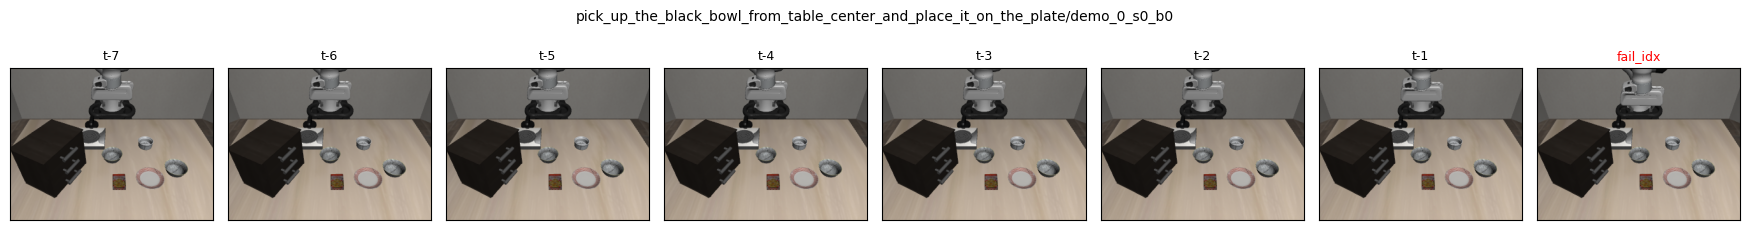

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


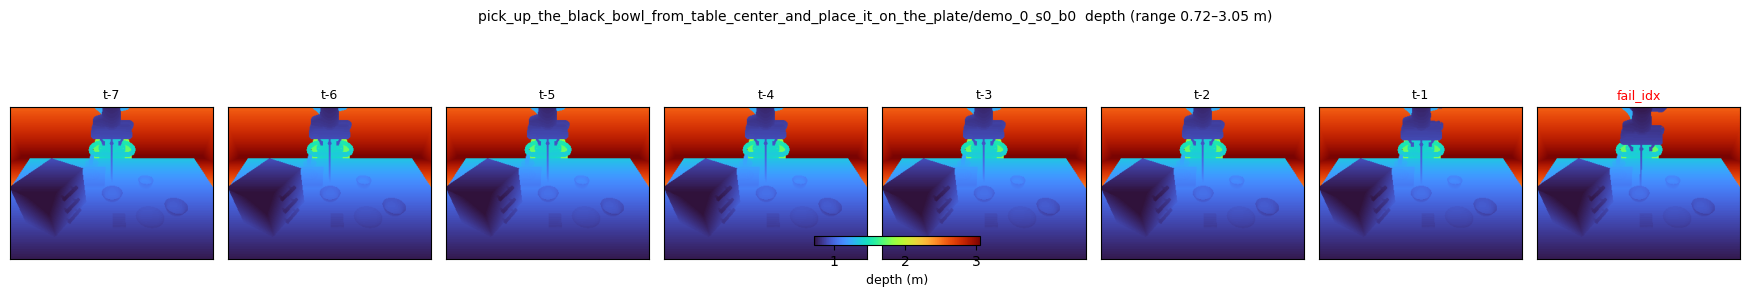

In [ ]:
show_window(s)
show_window(s, depth=True)

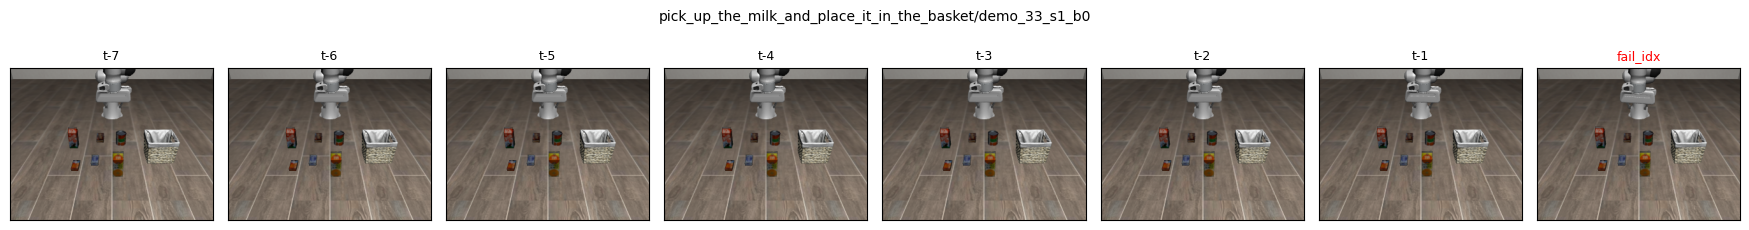

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


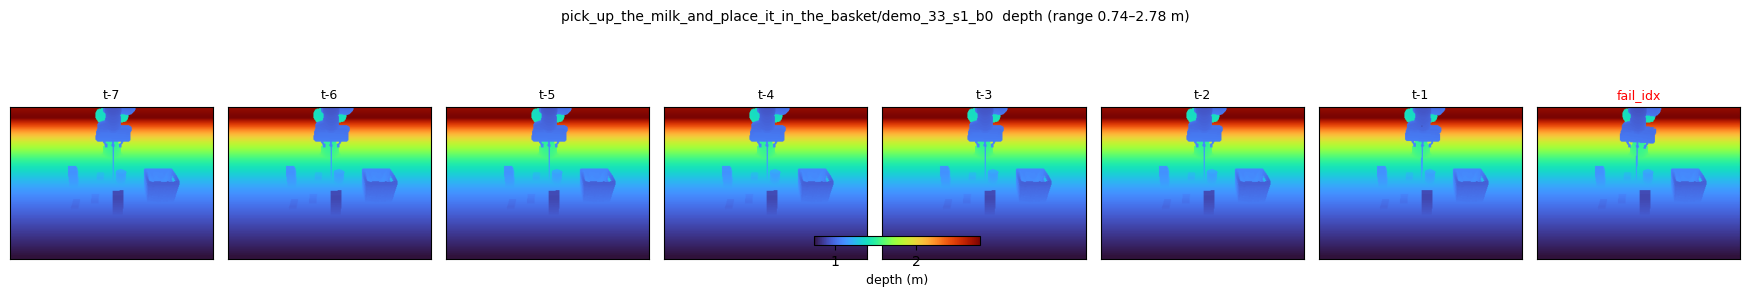

In [ ]:
show_window(dataset[25000])
show_window(dataset[25000], depth=True)

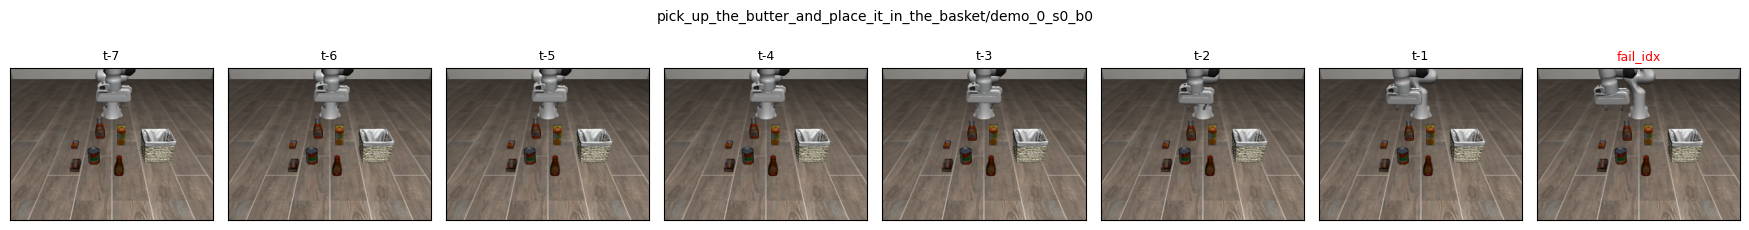

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


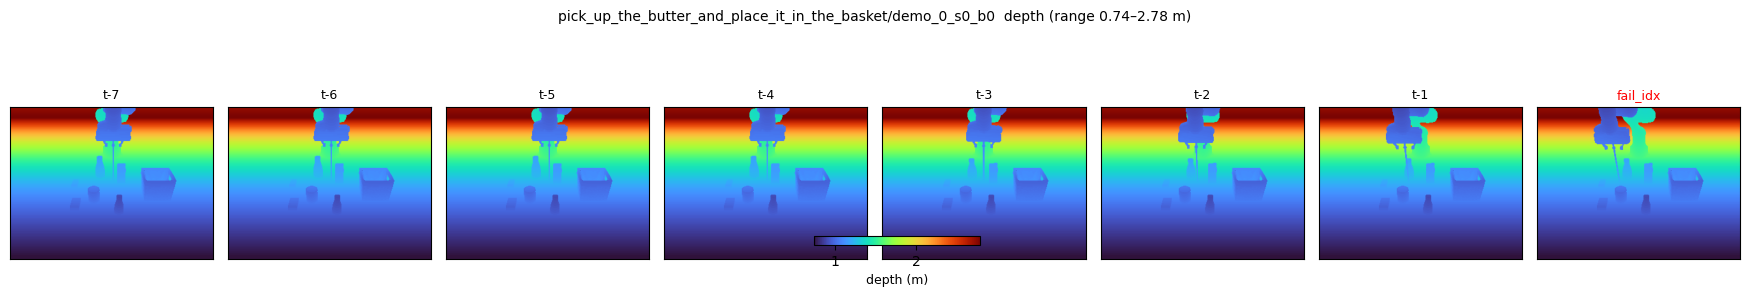

In [ ]:
show_window(dataset[18000])
show_window(dataset[18000], depth=True)

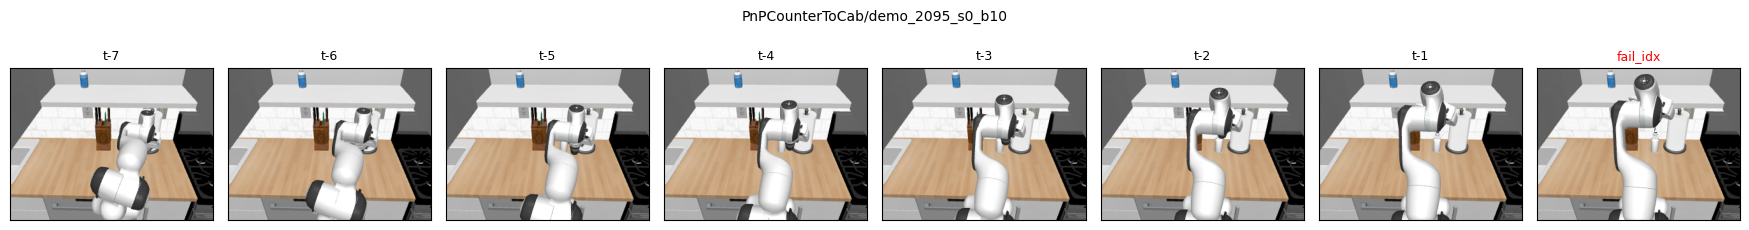

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


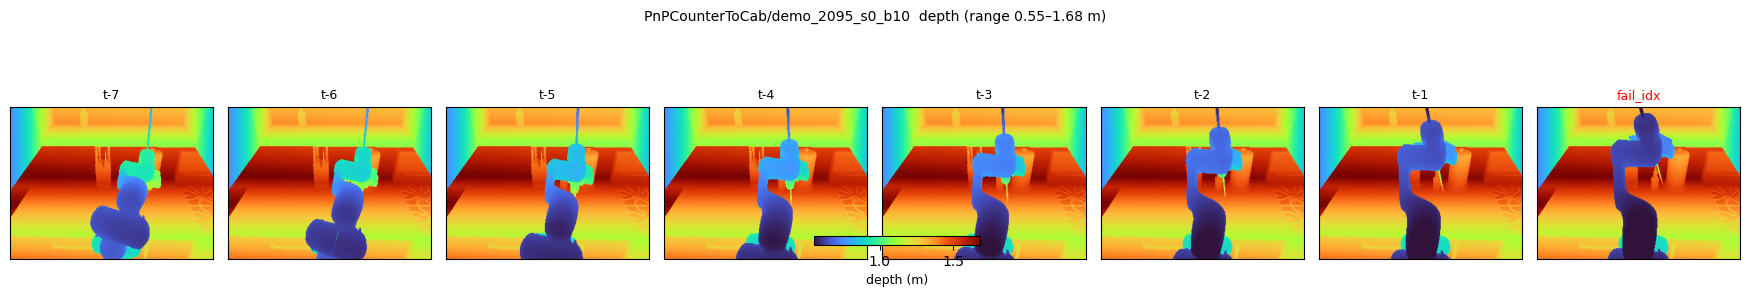

In [ ]:
show_window(dataset[52000])
show_window(dataset[52000], depth=True)

In [ ]:
s['failure_joints']

array([0., 0., 0., 1., 0., 0., 0.], dtype=float32)

In [ ]:
s['failure_mode']

array([0., 0., 1., 0., 0.], dtype=float32)

In [ ]:
s['goal_offsets']

array([ 5, 15, 30], dtype=int32)

In [ ]:
# target
# target_log1p
# target_mass|

In [ ]:
s['target'].shape

(240, 320)

(240, 320)


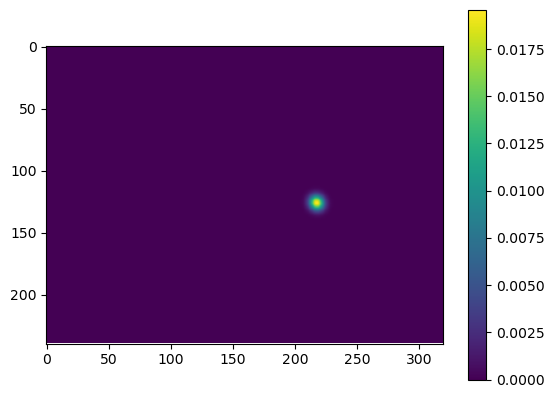

In [ ]:
tmp = dataset[107]


print(tmp['target'].shape)
plt.imshow(tmp['target'])
plt.colorbar()

In [ ]:
s['target']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

## Visualize input --> Output

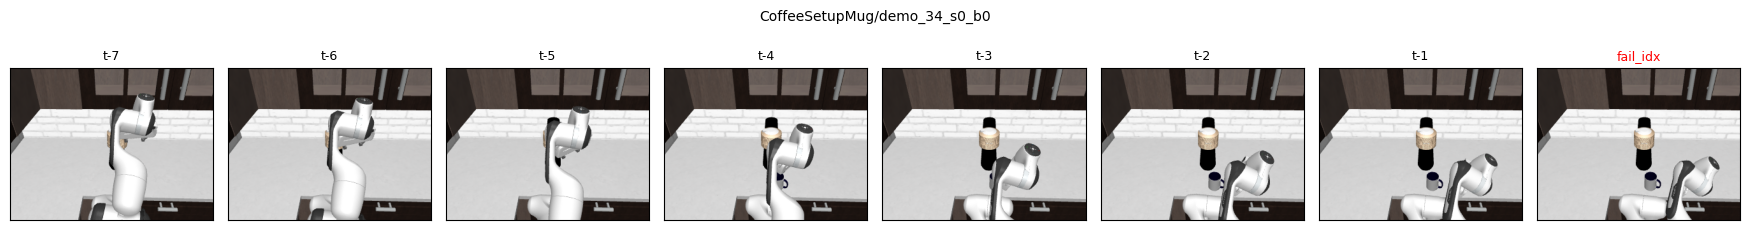

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


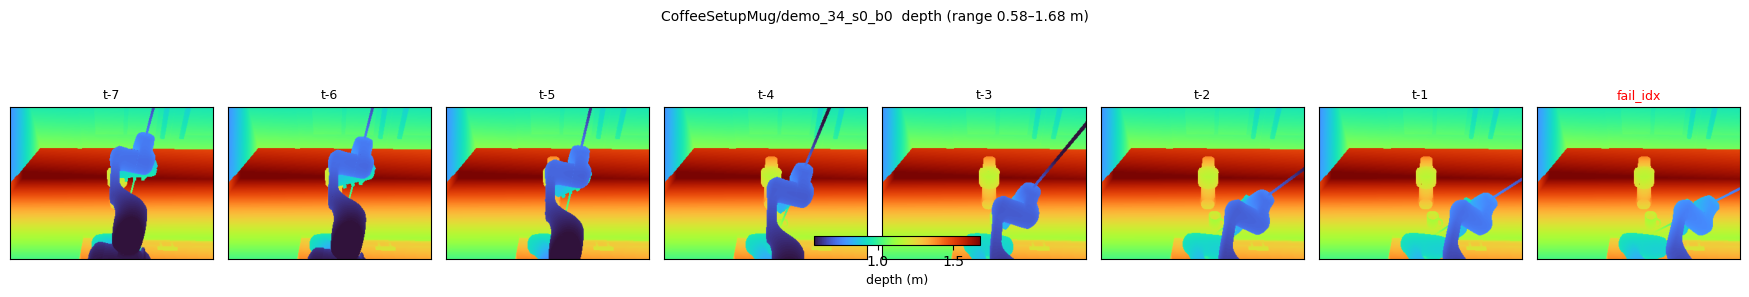

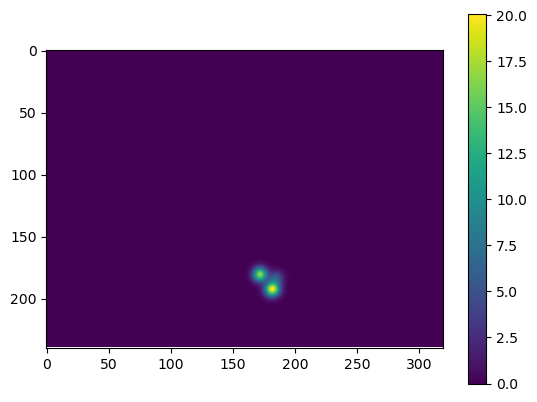

In [ ]:
tmp = dataset[45000]


show_window(tmp)
show_window(tmp, depth=True)
##################3
plt.imshow(tmp['target'])
plt.colorbar()

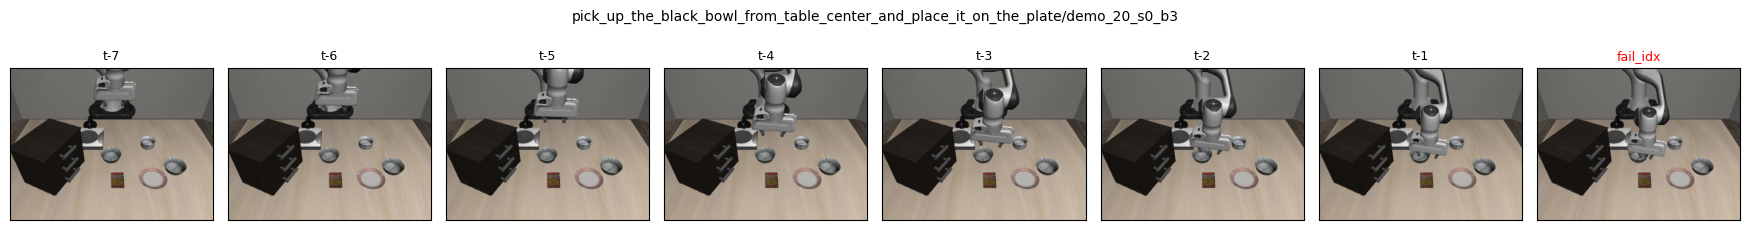

/tmp/ipykernel_2547928/3263156142.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


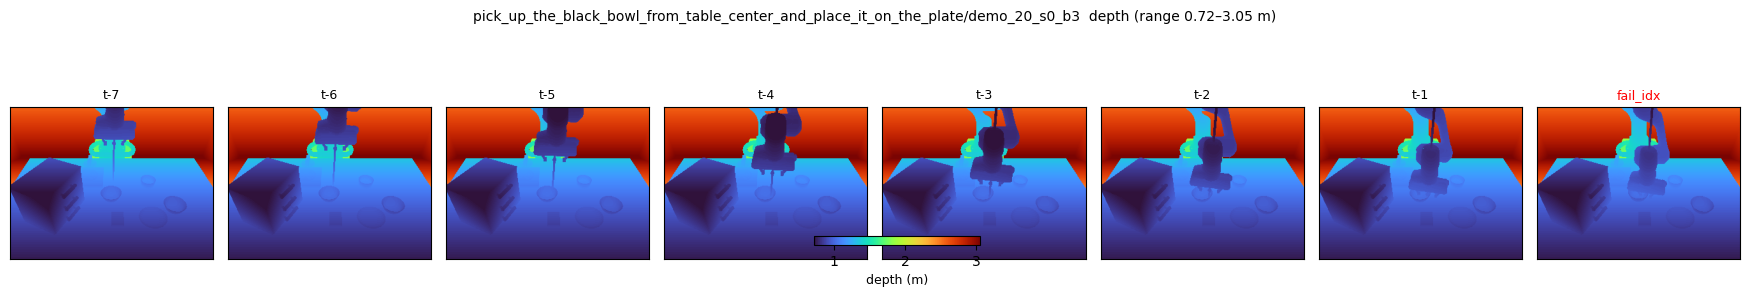

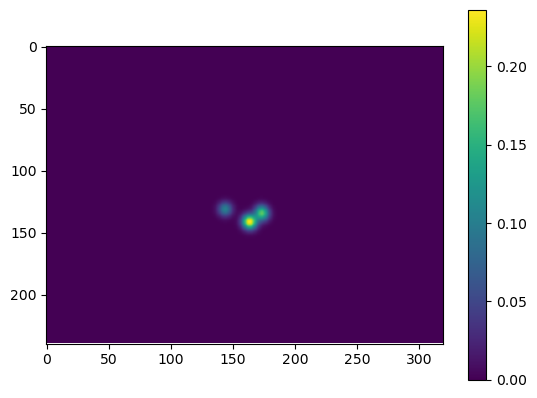

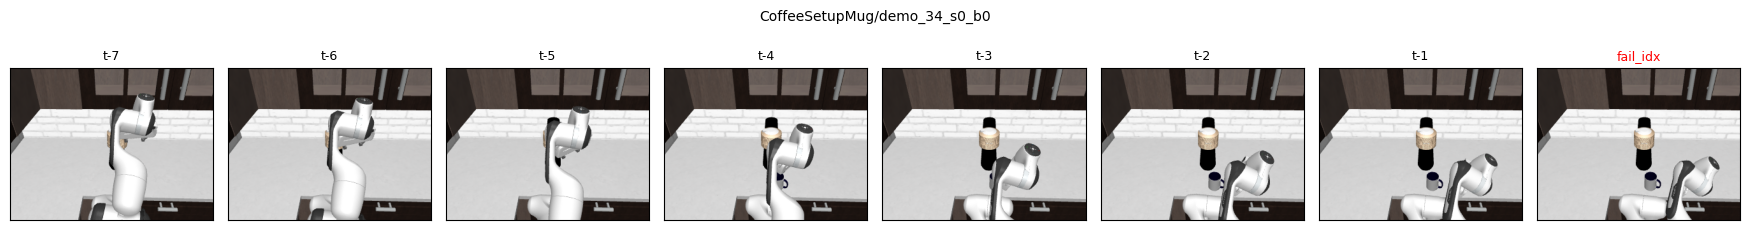

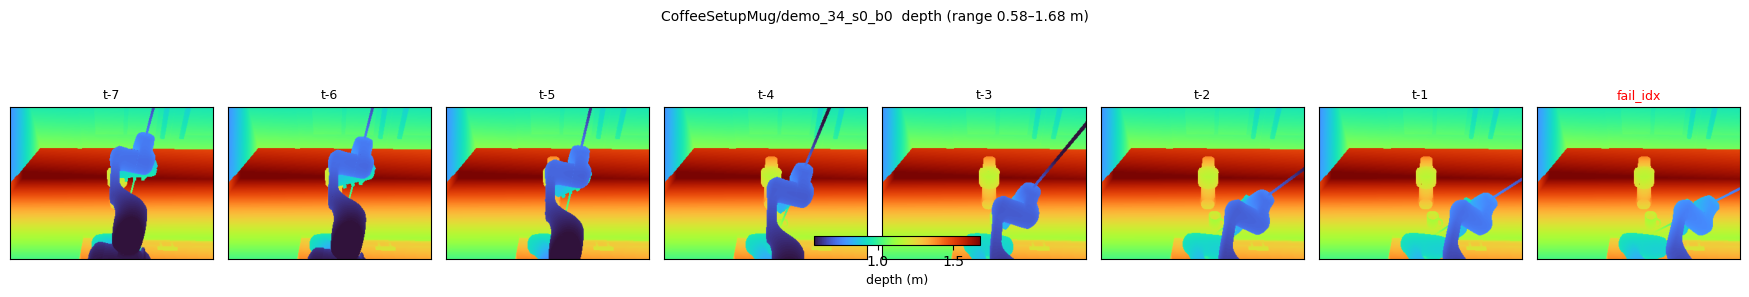

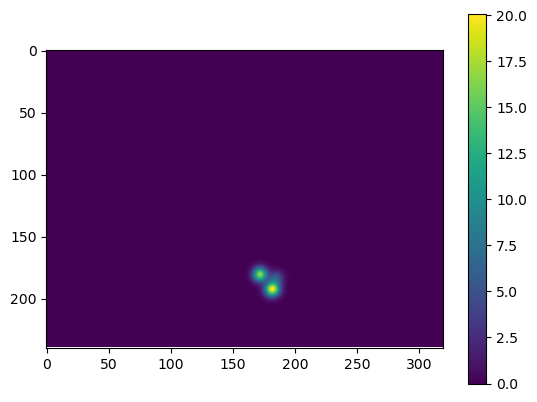

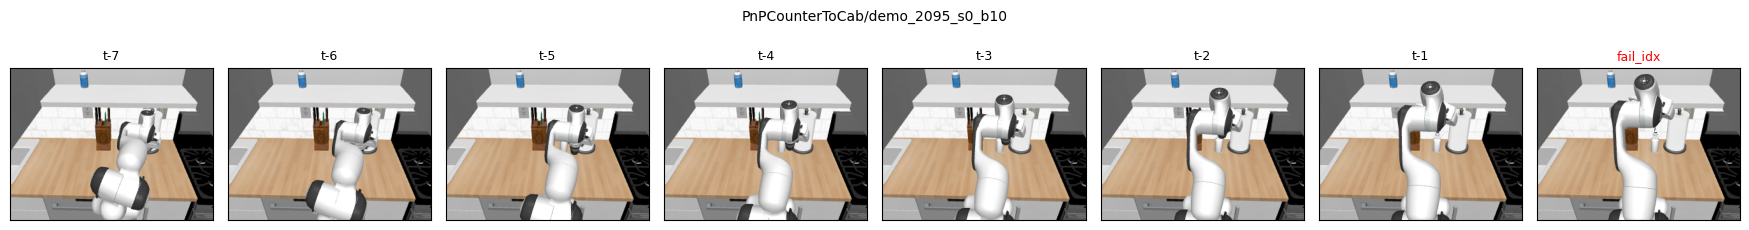

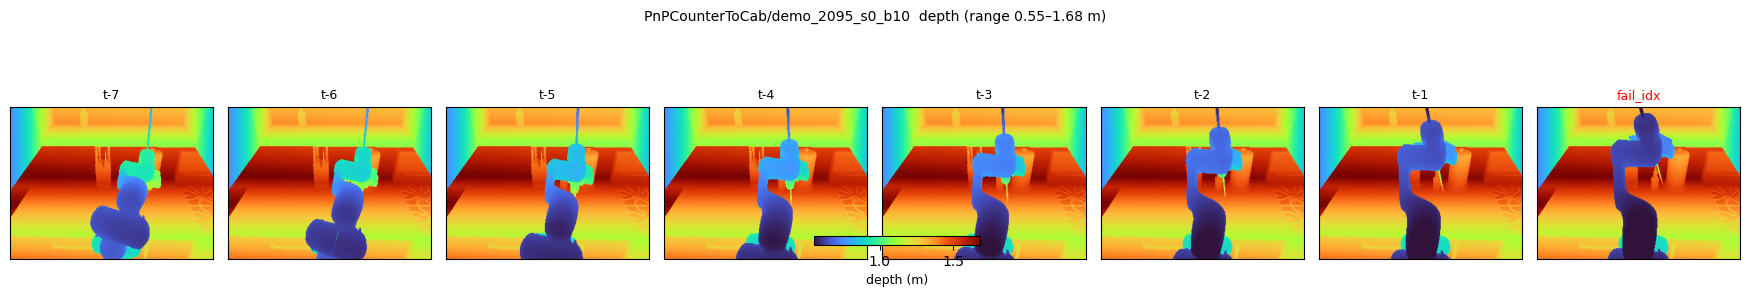

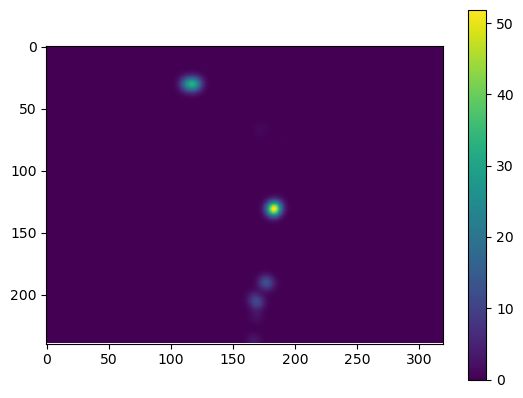

In [ ]:
for id in [603, 45000, 52000]:
    tmp = dataset[id]
    show_window(tmp)
    show_window(tmp, depth=True)
    ##################3
    plt.imshow(tmp['target'])
    plt.colorbar()

## Super-simple MLP baseline

A state-only MLP that regresses the agentview contact heatmap. Intended as the
**floor** of the benchmark: if a fancier model can't beat this, it's not learning
anything useful. Everything below assumes you already have `dataset` from the cell
near the top and the standard sample keys produced by `BenchmarkDataset`.

**Design choices (deliberately simple):**

- **Input**: only **state + failure descriptor** — no images. State alone explains
  most of "where the arm ends up" because the failure boundary pose is already
  in `state_window[-1]`. RGB/depth go in next-iteration models.
- **Architecture**: one hidden layer (256 units). No batch-norm, no dropout, no
  weight decay. Adam at 3e-4.
- **Output**: a single dense `Linear → H * W` head that reshapes to `(H, W)`.
  At `(240 × 320) = 76,800` outputs this is the biggest layer by a mile (~20 M
  params vs ~40 K for the input + hidden). The next architecture iteration would
  replace this with a `ConvTranspose` decoder so adjacent pixels share params.
- **Target**: `target_log1p` (the log-compressed version of the heatmap). The
  raw `target` has spiky 99-percentile values and a 99 % zero-pixel tail; the
  log1p compresses both and is what the benchmark trainer regresses.
- **Loss**: foreground-reweighted MSE. Without reweighting the ~1 % foreground
  pixels get drowned by the ~99 % zero pixels and the model converges to
  "predict 0 everywhere". `w = 1 + alpha * (target > 0)` with α=10 gives them
  ~10× the gradient.


In [11]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import numpy as np

from planner.risk.benchmark_dataset import demo_stratified_split
from planner.risk.v2_targets import build_target_from_projection


# ----------------------------------------------------------------------
# 1.  Collate function. When target_cache_root is set the dataset returns
#     variable-length target_projection per trial, so we pad to the
#     batch's max length and produce a mask. Other ndarray fields stack
#     normally; strings pass through as lists.
# ----------------------------------------------------------------------
def _collate(batch):
    out = {}
    for k in batch[0]:
        v0 = batch[0][k]
        if k == "target_projection":
            # Flat-sparse: concatenate across batch + carry batch_idx.
            # Per-trial counts vary by 10x+ so padding wastes memory.
            arrs = [b[k] for b in batch]
            if arrs and any(a.shape[0] for a in arrs):
                flat = np.concatenate(arrs, axis=0)
                batch_idx = np.concatenate([
                    np.full(a.shape[0], i, dtype=np.int64)
                    for i, a in enumerate(arrs)
                ])
            else:
                flat = np.zeros((0, 3), dtype=np.float32)
                batch_idx = np.zeros((0,), dtype=np.int64)
            out["target_projection_flat"] = torch.from_numpy(flat)
            out["target_projection_batch_idx"] = torch.from_numpy(batch_idx)
        elif isinstance(v0, np.ndarray):
            out[k] = torch.from_numpy(np.stack([b[k] for b in batch]))
        elif isinstance(v0, (np.floating, np.integer, float, int)):
            out[k] = torch.tensor([float(b[k]) for b in batch], dtype=torch.float32)
        else:
            out[k] = [b[k] for b in batch]
    return out


# ----------------------------------------------------------------------
# 2.  Train/val split (demo-stratified).
# ----------------------------------------------------------------------
train_idx, val_idx = demo_stratified_split(dataset, val_frac=0.10, seed=0)

# ----------------------------------------------------------------------
# 3.  DataLoader. num_workers=0 is fastest for this dataset (per-trial
#     work is moderate, sample payload is small, IPC overhead dominates).
# ----------------------------------------------------------------------
BATCH = 64
# num_workers=8 measured ~2.7 min/epoch (vs ~6.5 min at nw=0); 16 hits
# ~1.9 min but with diminishing returns. Workers are now safe because the
# pickled per-sample payload is small (~25 KB) when target_cache + state-only
# modalities are in use, and the quarantine has filtered out the corrupt
# trials that used to crash workers.
NUM_WORKERS = 8
train_loader = DataLoader(
    Subset(dataset, train_idx),
    batch_size=BATCH, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=(NUM_WORKERS > 0),
    collate_fn=_collate,
)
val_loader = DataLoader(
    Subset(dataset, val_idx),
    batch_size=BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    collate_fn=_collate,
)
print(f"train: {len(train_idx):,} trials | val: {len(val_idx):,} trials")
print(f"batches/epoch: train={len(train_loader)} val={len(val_loader)} (batch_size={BATCH})")


# ----------------------------------------------------------------------
# 4.  Build input + model + loss + a wrapper that builds the target on GPU.
# ----------------------------------------------------------------------
H, W = 240, 320
SIGMA_PX = 4.0
LOG1P = True

def build_input(batch):
    state = batch["state_window"].float().flatten(start_dim=1)   # (B, 144)
    mode  = batch["failure_mode"].float()                          # (B, 5)
    joint = batch["failure_joints"].float()                        # (B, 7)
    return torch.cat([state, mode, joint], dim=-1)                 # (B, 156)


def build_target(batch, device):
    """Rebuild the (B, H, W) target from cached projections, on device."""
    proj_flat = batch["target_projection_flat"].to(device, non_blocking=True)
    batch_idx = batch["target_projection_batch_idx"].to(device, non_blocking=True)
    fp        = batch["failure_prob"].to(device, non_blocking=True)
    return build_target_from_projection(
        proj_flat, batch_idx, fp, H=H, W=W, sigma_px=SIGMA_PX, log1p=LOG1P,
    )


class TinyMLP(nn.Module):
    def __init__(self, in_dim, hidden, H, W):
        super().__init__()
        self.H, self.W = H, W
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, H * W),
        )
    def forward(self, x): return self.net(x).view(-1, self.H, self.W)


def weighted_mse_log1p(pred, target_log1p, alpha=10.0):
    fg = (target_log1p > 0).float()
    w  = 1.0 + alpha * fg
    return (w * (pred - target_log1p) ** 2).mean()


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model  = TinyMLP(in_dim=156, hidden=256, H=H, W=W).to(DEVICE)
opt    = torch.optim.Adam(model.parameters(), lr=3e-4)
print(f"device: {DEVICE}  params: {sum(p.numel() for p in model.parameters()):,}")


# ----------------------------------------------------------------------
# 5.  Real training loop with per-step timing.
# ----------------------------------------------------------------------
def train_epoch(model, loader, opt, device, log_every=50):
    model.train()
    losses, t_data, t_compute = [], 0.0, 0.0
    t_last = time.time()
    n_batches = len(loader)
    t_epoch_start = time.time()
    for step, batch in enumerate(loader):
        t_data += time.time() - t_last
        t0 = time.time()
        # Move tensors to device
        b_dev = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
                 for k, v in batch.items()}
        # Build target on GPU from cached projection
        target = build_target(batch, device)
        pred = model(build_input(b_dev))
        loss = weighted_mse_log1p(pred, target)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        t_compute += time.time() - t0
        if (step + 1) % log_every == 0:
            dt = time.time() - t_epoch_start
            rate = (step + 1) / max(dt, 1e-6)
            eta = (n_batches - step - 1) / max(rate, 1e-6)
            print(f"  step {step+1:4d}/{n_batches}  loss={loss.item():.4f}  "
                  f"{rate:.1f} batch/s  ETA {eta/60:.1f} min  "
                  f"data_frac={t_data/(t_data+t_compute):.2f}")
        t_last = time.time()
    return {"loss_mean": float(np.mean(losses)),
            "loss_first": losses[0], "loss_last": losses[-1],
            "data_sec": t_data, "compute_sec": t_compute,
            "epoch_sec": time.time() - t_epoch_start}


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    losses = []
    for batch in loader:
        b_dev = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
                 for k, v in batch.items()}
        target = build_target(batch, device)
        pred = model(build_input(b_dev))
        losses.append(weighted_mse_log1p(pred, target).item())
    return float(np.mean(losses))


# Warm-up + one real epoch + val
print("warming up loader...")
t0 = time.time(); _ = next(iter(train_loader)); print(f"  first batch in {time.time()-t0:.1f}s")

print("\n=== epoch 1 ===")
stats = train_epoch(model, train_loader, opt, DEVICE, log_every=50)
val_loss = eval_epoch(model, val_loader, DEVICE)
print(f"epoch 1: train_loss={stats['loss_mean']:.4f}  val_loss={val_loss:.4f}")
print(f"  data IO {stats['data_sec']/60:.1f} min  compute {stats['compute_sec']/60:.1f} min  "
      f"total {stats['epoch_sec']/60:.1f} min")
print(f"  data_frac={stats['data_sec']/(stats['data_sec']+stats['compute_sec']):.2f}  "
      f"({'IO-bound' if stats['data_sec'] > stats['compute_sec'] else 'compute-bound'})")


train: 46,994 trials | val: 5,160 trials
batches/epoch: train=734 val=81 (batch_size=64)
device: cuda  params: 19,777,792
warming up loader...
  first batch in 0.7s

=== epoch 1 ===
  step   50/734  loss=0.3053  4.6 batch/s  ETA 2.5 min  data_frac=0.91
  step  100/734  loss=0.2362  5.3 batch/s  ETA 2.0 min  data_frac=0.93
  step  150/734  loss=0.2492  5.7 batch/s  ETA 1.7 min  data_frac=0.93
  step  200/734  loss=0.2558  5.7 batch/s  ETA 1.6 min  data_frac=0.94
  step  250/734  loss=0.3256  5.9 batch/s  ETA 1.4 min  data_frac=0.94
  step  300/734  loss=0.2877  6.1 batch/s  ETA 1.2 min  data_frac=0.94
  step  350/734  loss=0.1966  6.2 batch/s  ETA 1.0 min  data_frac=0.94
  step  400/734  loss=0.2213  6.3 batch/s  ETA 0.9 min  data_frac=0.94
  step  450/734  loss=0.2412  6.4 batch/s  ETA 0.7 min  data_frac=0.94
  step  500/734  loss=0.2126  6.3 batch/s  ETA 0.6 min  data_frac=0.94
  step  550/734  loss=0.2146  6.4 batch/s  ETA 0.5 min  data_frac=0.94
  step  600/734  loss=0.2228  6.5 bat